# Transfer Learning

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
import numpy as np

In [2]:
X_train = np.load("../dataset/X_train.npy")
y_train = np.load("../dataset/y_train.npy")

X_val = np.load("../dataset/X_val.npy")
y_val = np.load("../dataset/y_val.npy")

X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

In [3]:
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val   = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test  = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [4]:
X_train = F.interpolate(X_train, size=(224, 224))
X_val   = F.interpolate(X_val, size=(224, 224))
X_test  = F.interpolate(X_test, size=(224, 224))

In [5]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [6]:
def train_model_batch(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")

    return train_losses, val_losses

In [7]:
model = models.resnet18(pretrained=True)

# Change output layer
model.fc = nn.Linear(model.fc.in_features, 2)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

train_losses, val_losses = train_model_batch(model, optimizer)

Epoch 1: Train Loss=0.6905, Val Loss=0.6165
Epoch 2: Train Loss=0.5786, Val Loss=0.5324
Epoch 3: Train Loss=0.4961, Val Loss=0.4638
Epoch 4: Train Loss=0.4318, Val Loss=0.4122
Epoch 5: Train Loss=0.3822, Val Loss=0.3695
Epoch 6: Train Loss=0.3394, Val Loss=0.3364
Epoch 7: Train Loss=0.3087, Val Loss=0.3081
Epoch 8: Train Loss=0.2901, Val Loss=0.2830
Epoch 9: Train Loss=0.2611, Val Loss=0.2657
Epoch 10: Train Loss=0.2490, Val Loss=0.2483


In [9]:
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)

accuracy = (preds == y_test).float().mean()
print("Transfer Learning Accuracy:", accuracy.item())

Transfer Learning Accuracy: 0.9428571462631226


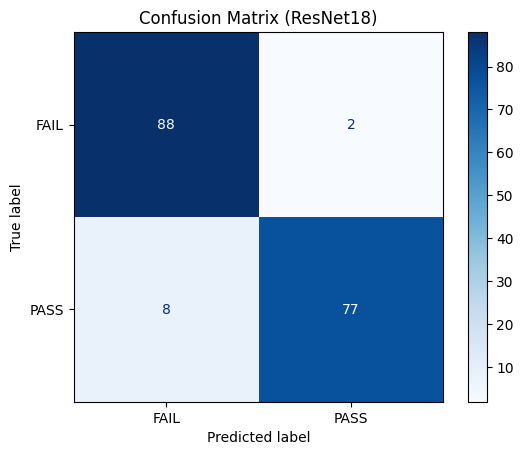

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test.numpy(), preds.numpy())

disp = ConfusionMatrixDisplay(cm, display_labels=["FAIL", "PASS"])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix (ResNet18)")
plt.show()